# Diabetes Prediction Using Machine Learning (KNN Algorithm) 
 
# Dataset:  Pima Indians Diabetes Dataset 

In [1]:
#Objective 
#• Implement KNN algorithm for diabetes prediction 
#• Perform feature scaling 
#• Visualize results 
#• Evaluate model performance 

In [2]:
# import liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("diabetes.csv")
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
#define feartures and terget
X=df.drop("Outcome",axis=1)
y=df["Outcome"]

In [5]:
#split Dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
#Feature Scaling (Very Important for KNN) 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [7]:
#Apply KNN algorithm
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
#make predictions
y_pred=knn.predict(X_test)

In [9]:
#Evaluate Model 
print("Accuracy:", accuracy_score(y_test, y_pred)) 
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
print("\nClassification Report:\n", classification_report(y_test, y_pred)) 

#Expected Accuracy: Around 70% – 80%

Accuracy: 0.6948051948051948

Confusion Matrix:
 [[79 20]
 [27 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154



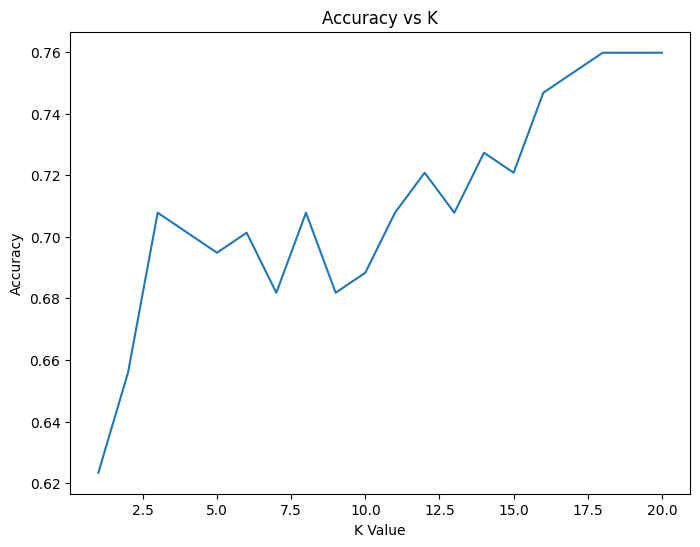

In [10]:
#Visualization 1 – Accuracy vs K 
accuracy = [] 
 
for k in range(1, 21): 
    model = KNeighborsClassifier(n_neighbors=k) 
    model.fit(X_train, y_train) 
    y_pred_k = model.predict(X_test) 
    accuracy.append(accuracy_score(y_test, y_pred_k)) 
 
plt.figure(figsize=(8,6)) 
plt.plot(range(1, 21), accuracy) 
plt.xlabel("K Value") 
plt.ylabel("Accuracy") 
plt.title("Accuracy vs K") 
plt.show()

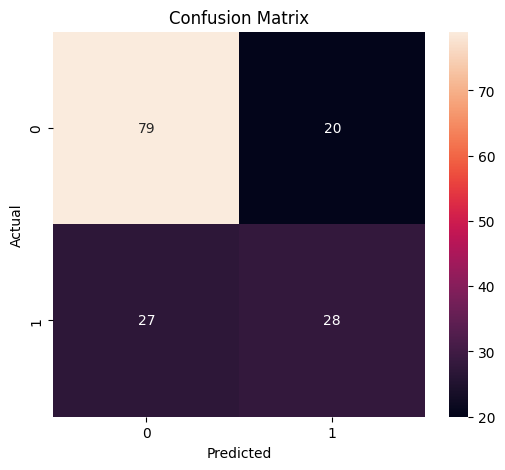

In [11]:
#Visualization 2 – Confusion Matrix Heatmap 
import seaborn as sns 
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt="d") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.title("Confusion Matrix") 
plt.show()

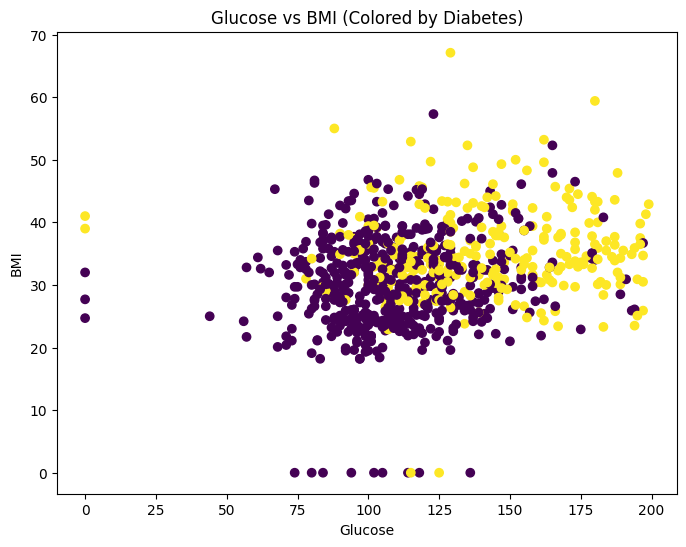

In [12]:
#Glucose vs BMI Scatter Plot 
plt.figure(figsize=(8,6)) 
plt.scatter(df["Glucose"], df["BMI"], c=df["Outcome"]) 
plt.xlabel("Glucose") 
plt.ylabel("BMI") 
plt.title("Glucose vs BMI (Colored by Diabetes)") 
plt.show()

In [13]:
#Now let’s improve your Diabetes Prediction using KNN by adding: 
#Hyperparameter Tuning using GridSearchCV 
#ROC Curve Visualization 
#This will make your practical more advanced and exam-ready.

In [14]:
#Hyperparameter Tuning using GridSearchCV 
#Import GridSearchCV 
from sklearn.model_selection import GridSearchCV 

In [15]:
#Define Parameter Grid 
param_grid = { 
    'n_neighbors': range(1, 21), 
    'weights': ['uniform', 'distance'], 
    'metric': ['euclidean', 'manhattan'] 
}

In [16]:
#Apply GridSearch 
grid = GridSearchCV( 
    KNeighborsClassifier(), 
    param_grid, 
 
 
    cv=5, 
    scoring='accuracy' 
) 
 
grid.fit(X_train, y_train) 

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': range(1, 21), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [17]:
#Best Parameters 
print("Best Parameters:", grid.best_params_) 
print("Best Cross Validation Accuracy:", grid.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Best Cross Validation Accuracy: 0.7655337864854058


In [18]:
#Use Best Model 
best_knn = grid.best_estimator_ 
 
y_pred = best_knn.predict(X_test) 
 
print("Test Accuracy:", accuracy_score(y_test, y_pred)) 

Test Accuracy: 0.6948051948051948


In [19]:
#ROC Curve Visualization 
    #What is ROC Curve? 
#ROC (Receiver Operating Characteristic) curve shows: 
#• True Positive Rate (Sensitivity) 
#• False Positive Rate 
#It helps measure classification performance.

In [20]:
#Import Required Libraries 
from sklearn.metrics import roc_curve, roc_auc_score 

In [21]:
#Get Probability Scores 
#KNN must use predict_proba(): 
 
y_prob = best_knn.predict_proba(X_test)[:,1]

In [24]:
#Calculate ROC Values 
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
auc_score = roc_auc_score(y_test, y_prob) 
 
print("AUC Score:", auc_score) 

AUC Score: 0.7709825528007346


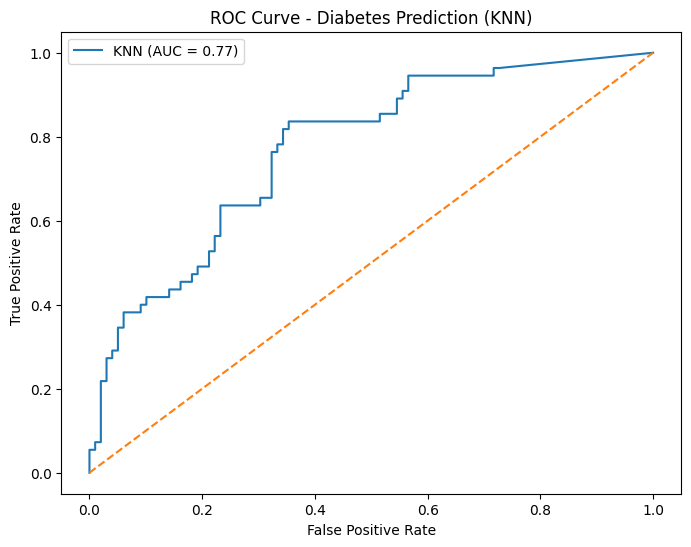

In [25]:
#Plot ROC Curve 
import matplotlib.pyplot as plt 
 
plt.figure(figsize=(8,6)) 
plt.plot(fpr, tpr, label="KNN (AUC = %0.2f)" % auc_score) 
plt.plot([0,1], [0,1], linestyle='--')  # Random line 
 
plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate") 
plt.title("ROC Curve - Diabetes Prediction (KNN)") 
plt.legend() 
plt.show() 

In [ ]:
#Interpretation 
#• AUC = 0.5 → Bad model 
#• AUC = 0.7–0.8 → Good model 
#• AUC = 0.8–0.9 → Very good 
#• AUC > 0.9 → Excellent 
#For diabetes dataset, expected AUC ≈ 0.75 – 0.85 